In [9]:
# stage2_compare.py
# Loads 1-second downsampled files and produces:
# - Group mean time-series plots (0–240 s) for each signal
# - Per-participant boxplots (mean over 0–240 s) across groups
# - CSV summaries for both
#
# Folder layout assumed (created by stage 1):
# result folder/data/processed/downsampled/{conventional, vr_high, vr_low, stress}/*.csv
# result folder/data/processed/hrv/{...}/*.csv  (optional aggregation at the end)

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()

PROJ_ROOT   = HERE
PROC_ROOT   = PROJ_ROOT / "data" / "processed"
DS_ROOT     = PROC_ROOT / "downsampled"
HRV_ROOT    = PROC_ROOT / "hrv"
FIG_DIR     = PROC_ROOT / "figures"
SUM_DIR     = PROC_ROOT / "summaries"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SUM_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
# Main comparison groups:
GROUPS = ["conventional", "vr_high", "vr_low"]
# OPTIONAL: include stress in time-series overlay for context (not in boxplot comparison)
INCLUDE_STRESS_IN_LINES = True

SIGNALS = ["SCL", "HR", "PVA", "TEMP", "MOTION"]  # add "SCR" if you want
MAX_SECONDS = 240

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def load_group(folder: Path, group: str) -> pd.DataFrame:
    gdir = folder / group
    if not gdir.exists():
        return pd.DataFrame()
    parts = []
    for f in sorted(gdir.glob("*.csv")):
        try:
            df = pd.read_csv(f)
        except Exception:
            continue
        if "sec" not in df.columns:
            continue
        df["participant"] = f.stem
        df["group"] = group
        parts.append(df)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

def group_mean_by_second(df_all: pd.DataFrame, signal: str) -> pd.DataFrame:
    use = df_all[["sec", "group", signal]].copy()
    use = use.dropna().loc[use["sec"] < MAX_SECONDS]
    grp = use.groupby(["group", "sec"], as_index=False)[signal].mean()
    grp.rename(columns={signal: f"{signal}_mean"}, inplace=True)
    return grp

def per_participant_mean(df_all: pd.DataFrame, signal: str) -> pd.DataFrame:
    use = df_all[["participant", "group", "sec", signal]].dropna()
    use = use[use["sec"] < MAX_SECONDS]
    agg = (use.groupby(["participant", "group"], as_index=False)[signal]
              .mean()
              .rename(columns={signal: f"{signal}_mean_0to240"}))
    return agg

def plot_group_lines(grp_means: pd.DataFrame, signal: str, stress_overlay: pd.DataFrame=None):
    fig, ax = plt.subplots(figsize=(10, 4))
    # Main groups
    for g in GROUPS:
        gdat = grp_means[grp_means["group"] == g]
        if not gdat.empty:
            ax.plot(gdat["sec"], gdat[f"{signal}_mean"], label=g, lw=1.5)
    # Optional stress overlay (dashed)
    if stress_overlay is not None and not stress_overlay.empty:
        ax.plot(stress_overlay["sec"], stress_overlay[f"{signal}_mean"],
                linestyle="--", linewidth=1.2, label="stress (ref)")
    ax.set_title(f"{signal} — Group mean over time (0–240 s)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(signal)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"lines_{signal}.png", dpi=150)
    plt.close(fig)

def plot_box(agg: pd.DataFrame, signal: str):
    fig, ax = plt.subplots(figsize=(6, 4))
    data = [agg.loc[agg["group"] == g, f"{signal}_mean_0to240"].dropna().values for g in GROUPS]
    ax.boxplot(data, labels=GROUPS, showmeans=True)
    ax.set_title(f"{signal} — Per-participant mean (0–240 s)")
    ax.set_ylabel(signal)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"box_{signal}.png", dpi=150)
    plt.close(fig)

def try_load_stress_mean_by_second(signal: str) -> pd.DataFrame:
    """If requested, compute stress group mean per second for overlay only."""
    if not INCLUDE_STRESS_IN_LINES:
        return pd.DataFrame()
    df = load_group(DS_ROOT, "stress")
    if df.empty or signal not in df.columns:
        return pd.DataFrame()
    return group_mean_by_second(df, signal)

# ------------------------------------------------------------
# HRV aggregation (optional): make group-level tables from HRV CSVs
# ------------------------------------------------------------
def aggregate_hrv():
    # Try to load HRV CSVs per group and compute simple group summaries
    rows = []
    for g in GROUPS:
        gdir = HRV_ROOT / g
        if not gdir.exists():
            continue
        for f in gdir.glob("*.csv"):
            try:
                h = pd.read_csv(f)
            except Exception:
                continue
            if h.empty:
                continue
            h["participant"] = f.stem
            h["group"] = g
            rows.append(h)
    if not rows:
        return
    hrv_all = pd.concat(rows, ignore_index=True)

    # Save raw stacked HRV
    hrv_all.to_csv(SUM_DIR / "hrv_all_participants.csv", index=False)

    # Per-group mean/SD for key metrics (ignore non-numeric)
    numeric_cols = hrv_all.select_dtypes(include=[np.number]).columns.tolist()
    grp_mean = hrv_all.groupby("group")[numeric_cols].mean().reset_index()
    grp_std  = hrv_all.groupby("group")[numeric_cols].std(ddof=1).reset_index()

    grp_mean.to_csv(SUM_DIR / "hrv_group_mean.csv", index=False)
    grp_std.to_csv(SUM_DIR / "hrv_group_std.csv", index=False)

# ------------------------------------------------------------
# Main
# ------------------------------------------------------------
def main():
    # Load comparison groups (downsampled)
    df_all_list = []
    for g in GROUPS:
        df_g = load_group(DS_ROOT, g)
        if not df_g.empty:
            df_all_list.append(df_g)

    if not df_all_list:
        print("No downsampled files found for comparison groups.")
        return

    df_all = pd.concat(df_all_list, ignore_index=True)

    # For each signal, make time-series and boxplots + CSVs
    for sig in SIGNALS:
        if sig not in df_all.columns:
            continue

        # Time-series group mean per second
        grp_means = group_mean_by_second(df_all, sig)

        # Optional stress overlay
        stress_overlay = try_load_stress_mean_by_second(sig)

        # Plot + save table
        plot_group_lines(grp_means, sig, stress_overlay if not stress_overlay.empty else None)
        grp_means.to_csv(SUM_DIR / f"group_mean_by_second_{sig}.csv", index=False)

        # Per-participant mean (0–240s) across groups (boxplot)
        agg = per_participant_mean(df_all, sig)
        plot_box(agg, sig)
        agg.to_csv(SUM_DIR / f"per_participant_mean_{sig}.csv", index=False)

    # Optional: aggregate HRV CSVs (if you want quick group tables)
    aggregate_hrv()

    print("Saved figures ->", FIG_DIR)
    print("Saved summaries ->", SUM_DIR)

if __name__ == "__main__":
    main()


C:\Users\HP'\AppData\Local\Temp\ipykernel_4120\701000301.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=GROUPS, showmeans=True)
C:\Users\HP'\AppData\Local\Temp\ipykernel_4120\701000301.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=GROUPS, showmeans=True)
C:\Users\HP'\AppData\Local\Temp\ipykernel_4120\701000301.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=GROUPS, showmeans=True)
C:\Users\HP'\AppData\Local\Temp\ipykernel_4120\701000301.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 

Saved figures -> d:\Git_repository\result folder\data\processed\figures
Saved summaries -> d:\Git_repository\result folder\data\processed\summaries


C:\Users\HP'\AppData\Local\Temp\ipykernel_4120\701000301.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=GROUPS, showmeans=True)


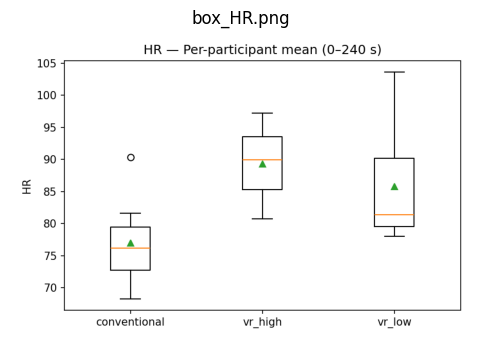

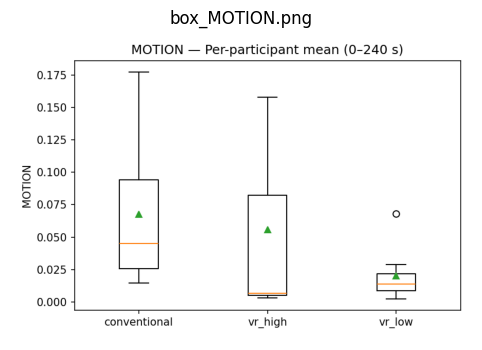

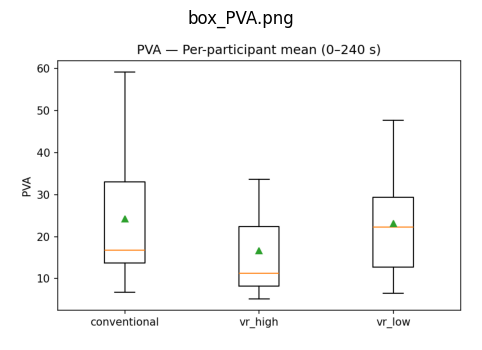

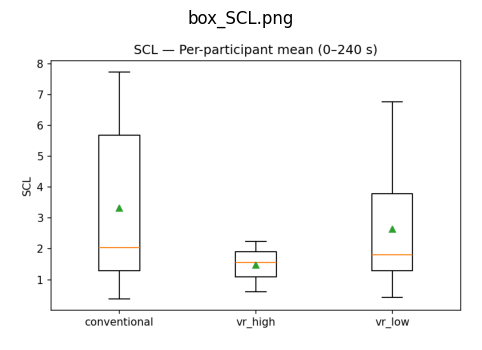

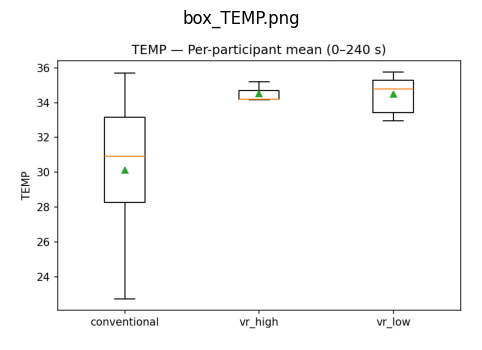

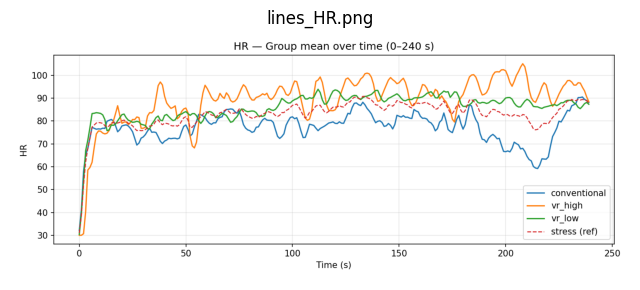

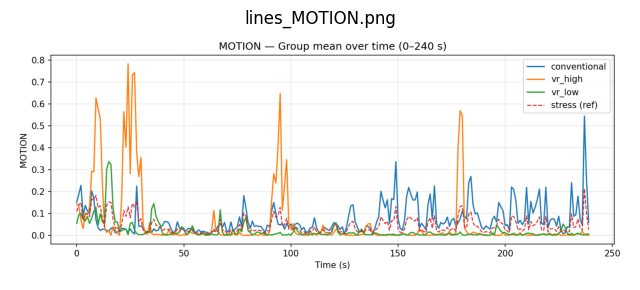

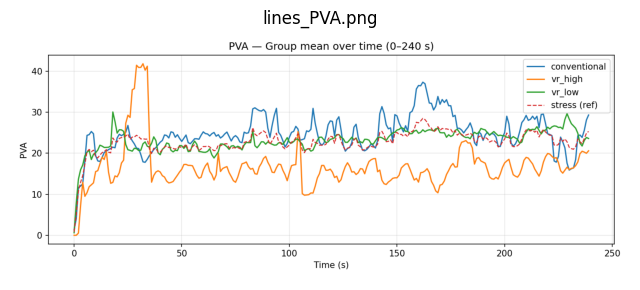

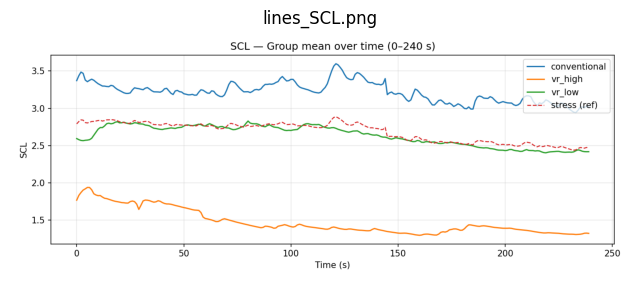

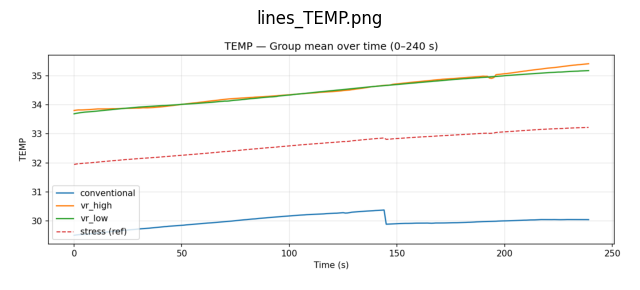

In [10]:
import matplotlib.pyplot as plt
import os

# Open all plots created in the FIG_DIR
for img in sorted(FIG_DIR.glob("*.png")):
    try:
        # Display image inline in VSCode or Jupyter
        img_data = plt.imread(img)
        plt.figure(figsize=(8, 4))
        plt.imshow(img_data)
        plt.axis("off")
        plt.title(img.name)
        plt.show()
    except Exception as e:
        print("Could not display:", img, "->", e)

✅ Loaded HRV data: (19, 11)
     ok  n_beats  mean_HR_bpm    SDNN_s   RMSSD_s  pNN50_percent  LF_power  \
0  True      193    79.314565  0.169247  0.224112      67.553191  0.001650   
1  True      467   112.615823  0.150046  0.204129      51.776650  0.002970   
2  True      516   119.090478  0.173938  0.221484      77.272727  0.005492   

   HF_power  LF_HF_ratio  participant         group  
0  0.002870     0.574822          100  conventional  
1  0.005371     0.553063          103  conventional  
2  0.010317     0.532337          105  conventional  

Group HRV Summary (mean ± SD):



,n_beats_mean,mean_HR_bpm_mean,SDNN_s_mean,RMSSD_s_mean,pNN50_percent_mean,LF_power_mean,HF_power_mean,LF_HF_ratio_mean,n_beats_std,mean_HR_bpm_std,SDNN_s_std,RMSSD_s_std,pNN50_percent_std,LF_power_std,HF_power_std,LF_HF_ratio_std
group,,,,,,,,,,,,,,,,
conventional,370.500000,94.047654,0.169110,0.223671,60.529694,0.005154,0.007849,0.690028,96.304576,14.660856,0.021773,0.025884,14.327155,0.002868,0.003916,0.323438
vr_high,446.333333,105.057634,0.129444,0.160535,44.097228,0.004560,0.003957,0.887867,127.946603,22.541694,0.034495,0.022650,12.082339,0.005707,0.002297,0.726791
vr_low,395.375000,97.191888,0.100482,0.122163,43.243730,0.002401,0.002954,1.271501,95.992466,21.507801,0.064841,0.095825,24.370656,0.002644,0.004940,1.236518


C:\Users\HP'\AppData\Local\Temp\ipykernel_4120\4271327243.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups, showmeans=True)


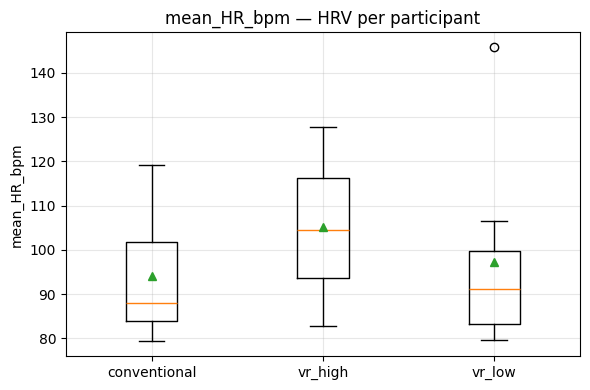

C:\Users\HP'\AppData\Local\Temp\ipykernel_4120\4271327243.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups, showmeans=True)


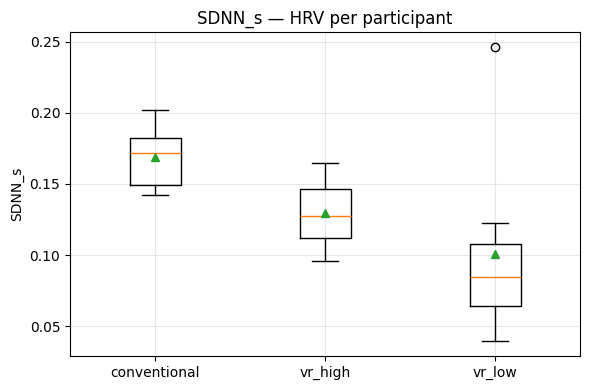

C:\Users\HP'\AppData\Local\Temp\ipykernel_4120\4271327243.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups, showmeans=True)


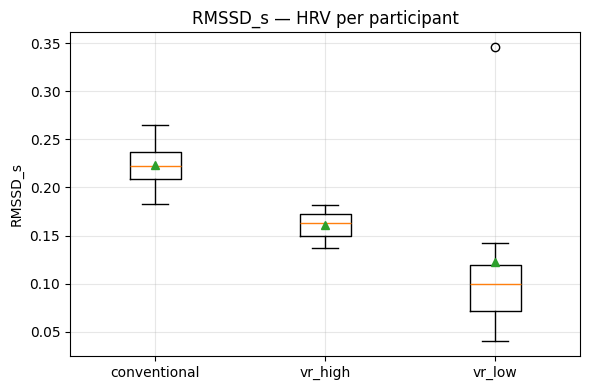

C:\Users\HP'\AppData\Local\Temp\ipykernel_4120\4271327243.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups, showmeans=True)


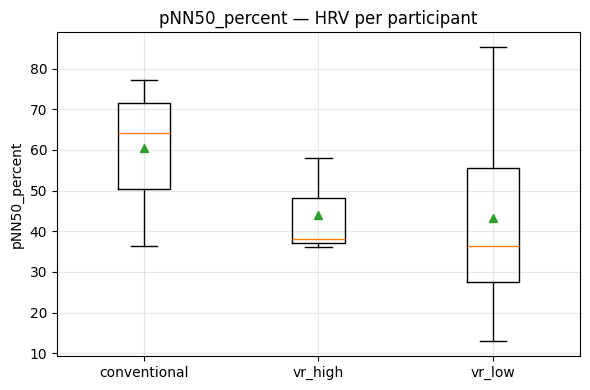

C:\Users\HP'\AppData\Local\Temp\ipykernel_4120\4271327243.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups, showmeans=True)


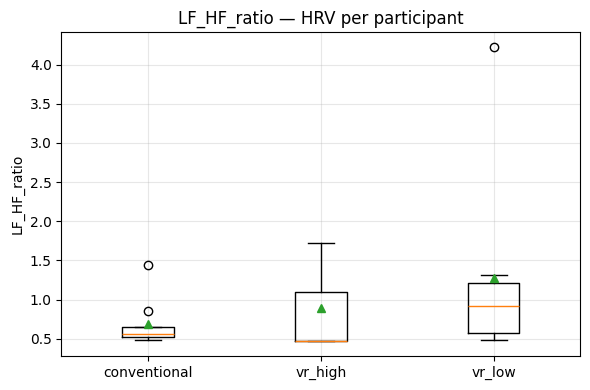

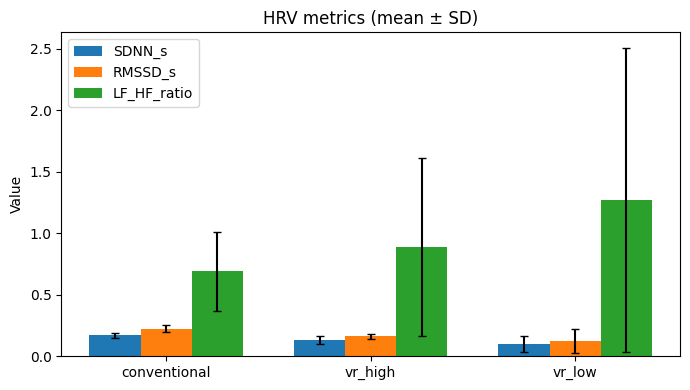

In [12]:
# view_hrv_results.py
# ------------------------------------------------------------
# Visualize HRV group summaries (SDNN, RMSSD, LF/HF ratio, etc.)
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Adjust this if needed
HRV_SUM_DIR = Path("data/processed/summaries")

# Load all HRV CSVs
hrv_all_path = HRV_SUM_DIR / "hrv_all_participants.csv"
hrv_mean_path = HRV_SUM_DIR / "hrv_group_mean.csv"
hrv_std_path  = HRV_SUM_DIR / "hrv_group_std.csv"

if not hrv_all_path.exists():
    raise FileNotFoundError("⚠️ hrv_all_participants.csv not found. Run Stage 2 first.")

hrv_all = pd.read_csv(hrv_all_path)
print("✅ Loaded HRV data:", hrv_all.shape)
print(hrv_all.head(3))

# ------------------------------------------------------------
# Example 1: quick summary table (mean ± SD per group)
# ------------------------------------------------------------
if hrv_mean_path.exists() and hrv_std_path.exists():
    mean_df = pd.read_csv(hrv_mean_path)
    std_df  = pd.read_csv(hrv_std_path)
    summary = mean_df.set_index("group")\
                     .join(std_df.set_index("group"), lsuffix="_mean", rsuffix="_std")
    print("\nGroup HRV Summary (mean ± SD):\n")
    display(summary)
else:
    print("⚠️ HRV mean/std files not found, skipping summary table.")

# ------------------------------------------------------------
# Example 2: boxplots per HRV metric across groups
# ------------------------------------------------------------
metrics_to_plot = ["mean_HR_bpm", "SDNN_s", "RMSSD_s", "pNN50_percent", "LF_HF_ratio"]
groups = hrv_all["group"].unique().tolist()

for metric in metrics_to_plot:
    if metric not in hrv_all.columns:
        continue

    fig, ax = plt.subplots(figsize=(6, 4))
    data = [hrv_all.loc[hrv_all["group"] == g, metric].dropna() for g in groups]
    ax.boxplot(data, labels=groups, showmeans=True)
    ax.set_title(f"{metric} — HRV per participant")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Example 3: optional bar plot for group mean ± SD
# ------------------------------------------------------------
if hrv_mean_path.exists() and hrv_std_path.exists():
    mean_df = pd.read_csv(hrv_mean_path)
    std_df  = pd.read_csv(hrv_std_path)

    key_metrics = ["SDNN_s", "RMSSD_s", "LF_HF_ratio"]
    fig, ax = plt.subplots(figsize=(7, 4))

    x = range(len(mean_df["group"]))
    width = 0.25

    for i, m in enumerate(key_metrics):
        ax.bar(
            [p + i * width for p in x],
            mean_df[m],
            width=width,
            label=m,
            yerr=std_df[m],
            capsize=3
        )

    ax.set_xticks([p + width for p in x])
    ax.set_xticklabels(mean_df["group"])
    ax.set_ylabel("Value")
    ax.set_title("HRV metrics (mean ± SD)")
    ax.legend()
    plt.tight_layout()
    plt.show()
